## 

## Quick restriction in PCK (6)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn

In [128]:
df1 = pd.read_csv('data/6/SIMULATED_00111.csv')
name = 'Sim_111'
path = f'../outputs/6/run4/{name}'

In [129]:
df1.head()

,timestamp,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL,class
0,2018-04-03 22:58:19.000000,22568840.0,15363580.0,NaN,1887250.0,86.24205,NaN,NaN,NaN,0
1,2018-04-03 22:58:20.000000,22568840.0,15363560.0,NaN,1887249.0,86.24205,NaN,NaN,NaN,0
2,2018-04-03 22:58:21.000000,22568840.0,15363550.0,NaN,1887249.0,86.24204,NaN,NaN,NaN,0
3,2018-04-03 22:58:22.000000,22568840.0,15363570.0,NaN,1887250.0,86.24204,NaN,NaN,NaN,0
4,2018-04-03 22:58:23.000000,22568840.0,15363600.0,NaN,1887249.0,86.24204,NaN,NaN,NaN,0


In [130]:
df1.drop(columns=['timestamp','T-TPT', 'T-JUS-CKP', 'T-JUS-CKGL', 'P-JUS-CKGL', 'QGL'], inplace=True)

In [131]:
df1.head()

,P-PDG,P-TPT,P-MON-CKP,class
0,22568840.0,15363580.0,1887250.0,0
1,22568840.0,15363560.0,1887249.0,0
2,22568840.0,15363550.0,1887249.0,0
3,22568840.0,15363570.0,1887250.0,0
4,22568840.0,15363600.0,1887249.0,0


In [132]:
tmp = df1.rename(columns= {'P-PDG': 'Pump outlet pressure (Mean)', 'P-TPT': 'TS inlet pressure (Mean)', 'P-MON-CKP': 'TS outlet pressure (Mean)'})

In [133]:
tmp['Differential pressure (Mean)'] = tmp['TS inlet pressure (Mean)'] - tmp['TS outlet pressure (Mean)']
tmp['Pump to inlet DP'] = tmp['Pump outlet pressure (Mean)'] - tmp['TS inlet pressure (Mean)']
tmp['Total system DP'] = tmp['Pump outlet pressure (Mean)'] - tmp['TS outlet pressure (Mean)']

In [134]:
baseline = tmp.iloc[:60]

tmp['rel_tot_dp_change'] = tmp['Total system DP'] / baseline['Total system DP'].median()
tmp['rel_ts_dp_change'] = tmp['Differential pressure (Mean)'] / baseline['Differential pressure (Mean)'].median()
tmp['rel_p_ts_dp_change'] = tmp['Pump to inlet DP'] / baseline['Pump to inlet DP'].median()

In [135]:
tmp['Pressure_Ratio'] = (tmp['TS inlet pressure (Mean)'] - tmp['TS outlet pressure (Mean)']) / \
                           (tmp['Pump outlet pressure (Mean)'] - tmp['TS inlet pressure (Mean)'] + 1e-6)

base_ratio_val = tmp['Pressure_Ratio'].iloc[:60].median()
    
tmp['Relative_Ratio_Dev'] = (tmp['Pressure_Ratio'] / (base_ratio_val + 1e-6) - 1).abs()

In [136]:
tmp.head()

,Pump outlet pressure (Mean),TS inlet pressure (Mean),TS outlet pressure (Mean),class,Differential pressure (Mean),Pump to inlet DP,Total system DP,rel_tot_dp_change,rel_ts_dp_change,rel_p_ts_dp_change,Pressure_Ratio,Relative_Ratio_Dev
0,22568840.0,15363580.0,1887250.0,0,13476330.0,7205260.0,20681590.0,1.0,1.000000,1.000000,1.870346,5.346601e-07
1,22568840.0,15363560.0,1887249.0,0,13476311.0,7205280.0,20681591.0,1.0,0.999999,1.000003,1.870338,4.720276e-06
2,22568840.0,15363550.0,1887249.0,0,13476301.0,7205290.0,20681591.0,1.0,0.999998,1.000004,1.870334,6.850177e-06
3,22568840.0,15363570.0,1887250.0,0,13476320.0,7205270.0,20681590.0,1.0,0.999999,1.000001,1.870342,2.664573e-06
4,22568840.0,15363600.0,1887249.0,0,13476351.0,7205240.0,20681591.0,1.0,1.000002,0.999997,1.870354,3.799387e-06


In [137]:
scaler = joblib.load('../../models/anomaly_scaler.joblib')
iso_model = joblib.load('../../models/anomaly_isolation_forest.joblib')

In [138]:
feature_cols = [
'rel_tot_dp_change', 'rel_ts_dp_change', 'rel_p_ts_dp_change','Relative_Ratio_Dev']

X_scaled = scaler.transform(tmp[feature_cols])
tmp['anomaly_score'] = iso_model.decision_function(X_scaled)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

feature_cols = [
    'rel_tot_dp_change', 
    'rel_ts_dp_change', 
    'rel_p_ts_dp_change',
    'Relative_Ratio_Dev',
    'anomaly_score'
]

class HydraulicLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, num_classes=4):
        super(HydraulicLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :]) 
        return out

model = HydraulicLSTM(input_size=len(feature_cols), hidden_size=64, num_layers=2, num_classes=4)
model.load_state_dict(torch.load('../../models/60sLstm.pth', map_location=device))
lstm_scaler = joblib.load('../../models/lstm_scaler.joblib')
model.to(device)
model.eval() 

predicted_states = [0] * 59 

with torch.no_grad(): 
    for current_sec in range(59, len(tmp)):
        window_raw = tmp[feature_cols].iloc[current_sec - 59 : current_sec + 1].values
        window_scaled = lstm_scaler.transform(window_raw)
        window_tensor = torch.tensor(window_scaled, dtype=torch.float32).unsqueeze(0).to(device)
        outputs = model(window_tensor)
        _, predicted_class = torch.max(outputs, 1)
        
        predicted_states.append(predicted_class.item())
tmp = tmp.copy()
tmp['predicted_state'] = predicted_states


In [140]:
tmp["elapsed_seconds"] = tmp.index.astype(int)

In [141]:
tmp[['predicted_state']].value_counts()

predicted_state
0                  26999
Name: count, dtype: int64

In [142]:
tmp['class'] = tmp['class'].replace(106, 3)

In [143]:
tmp['class'].value_counts()

class
6    17999
3     7200
0     1800
Name: count, dtype: int64

In [144]:
def plot_rdd(df):
    fig, ax = plt.subplots(figsize=(16, 6))

    x_axis = df['elapsed_seconds']

    ax.plot(x_axis, df['Relative_Ratio_Dev'], color='skyblue', alpha=0.4, label='Raw Deviation')

    smoothed = df['Relative_Ratio_Dev'].rolling(window=10, min_periods=1).mean()
    ax.plot(x_axis, smoothed, color='darkblue', linewidth=2, label='Smoothed Trend')

    ax.set_title(name + ' - Relative Ratio Deviation Over Time')
    ax.set_ylabel('Deviation Magnitude')
    ax.set_xlabel('Time (elapsed seconds)')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'{path}_relative_ratio_deviation.png', dpi=300)
    plt.show()

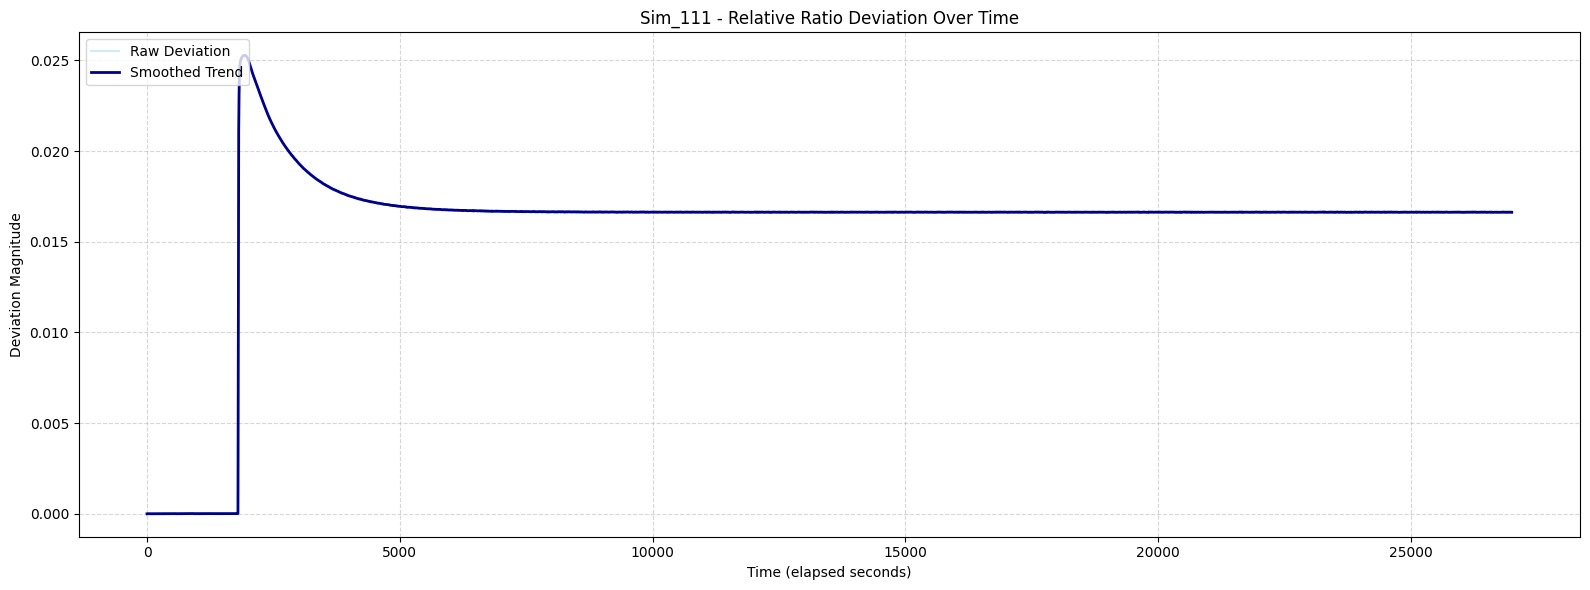

In [145]:
plot_rdd(tmp)

In [146]:
def plot_anomaly(df):
    fig, ax = plt.subplots(figsize=(16, 6))

    x_axis = df['elapsed_seconds']

    ax.plot(x_axis, df['anomaly_score'], color='skyblue', alpha=0.4, label='anomaly score')

    smoothed = df['anomaly_score'].rolling(window=10, min_periods=1).mean()
    ax.plot(x_axis, smoothed, color='darkblue', linewidth=2, label='Smoothed Trend')

    ax.set_title(name + ' - Anomaly Score Over Time')
    ax.set_ylabel(' Magnitude')
    ax.set_xlabel('Time (elapsed seconds)')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'{path}_anomaly_score.png', dpi=300)
    plt.show()

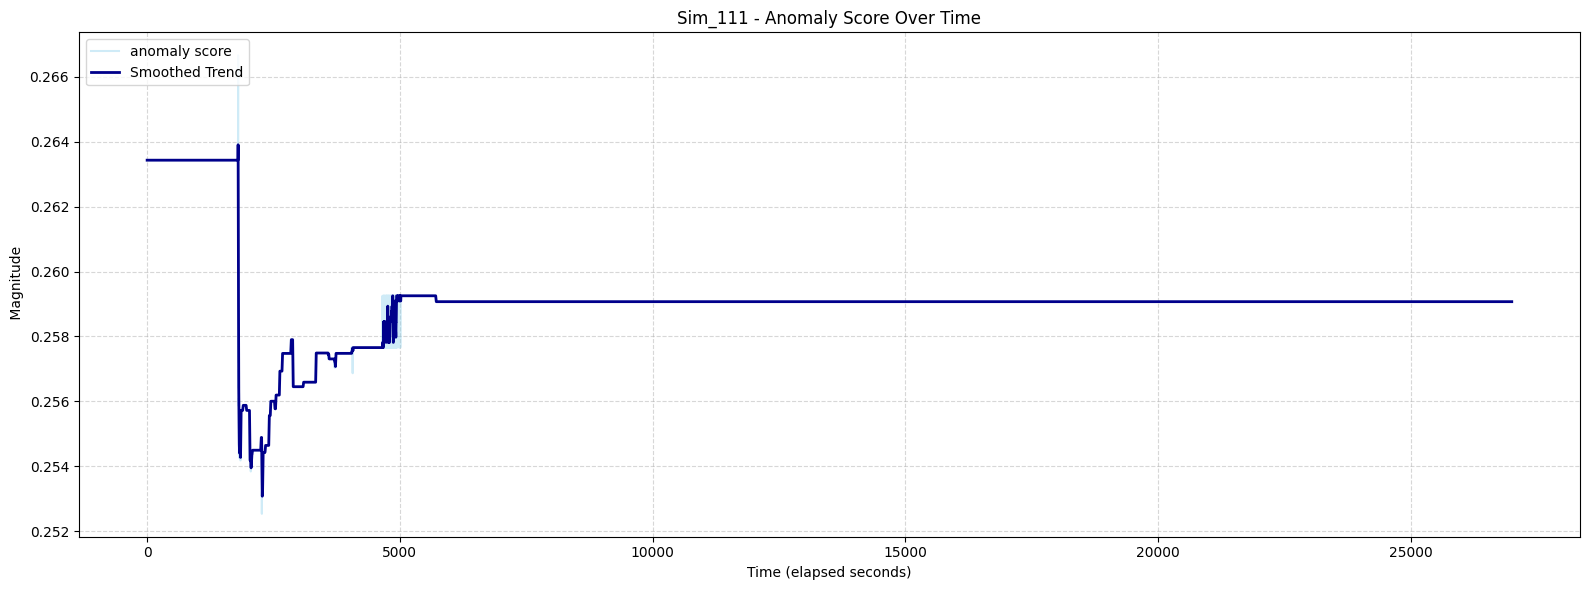

In [147]:
plot_anomaly(tmp)

In [148]:
def plot_pred(df):
    fig, ax = plt.subplots(figsize=(16, 6))

    x_axis = df['elapsed_seconds']

    ax.plot(x_axis, df['predicted_state'], color='skyblue', alpha=0.4, label='anomaly score')

    smoothed = df['predicted_state'].rolling(window=1, min_periods=1).mean()
    ax.plot(x_axis, smoothed, color='darkblue', linewidth=2, label='Smoothed Trend')

    ax.set_title('predicted label')
    ax.set_ylabel(' label')
    ax.set_xlabel('Time (elapsed seconds)')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'{path}_predicted_label.png', dpi=300)
    plt.show()

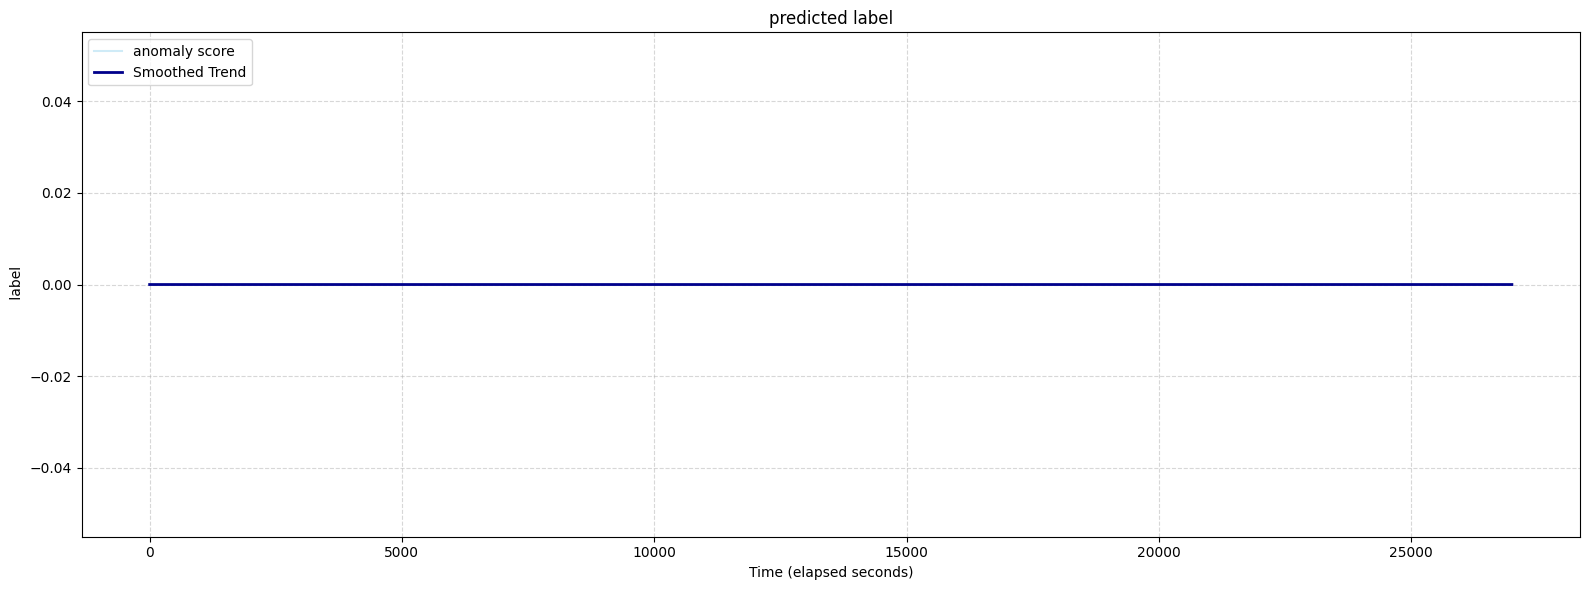

In [149]:
plot_pred(tmp)

In [150]:
def plot_class(df):
    fig, ax = plt.subplots(figsize=(16, 6))

    x_axis = df['elapsed_seconds']

    ax.plot(x_axis, df['class'], color='skyblue', alpha=0.4, label='anomaly score')

    smoothed = df['class'].rolling(window=1, min_periods=1).mean()
    ax.plot(x_axis, smoothed, color='darkblue', linewidth=2, label='Smoothed Trend')

    ax.set_title('actual label')
    ax.set_ylabel(' label')
    ax.set_xlabel('Time (elapsed seconds)')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'{path}_actual_label.png', dpi=300)
    plt.show()

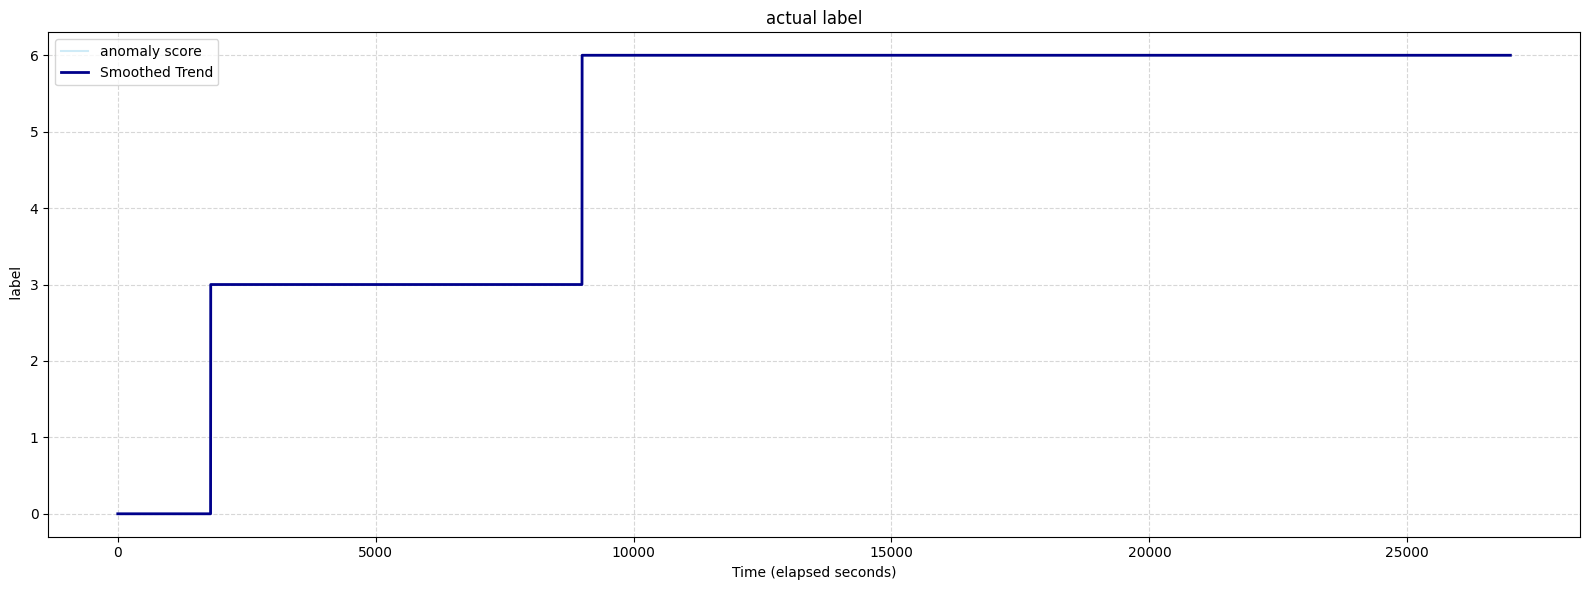

In [151]:
plot_class(tmp)